In [1]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import requests
from io import StringIO
from scipy.optimize import minimize, brentq
from scipy.interpolate import CubicSpline

# Plot style
plt.rcParams['figure.dpi']      = 150
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']       = True
plt.rcParams['grid.alpha']      = 0.3
plt.rcParams['grid.linestyle']  = '--'

---
---

# Bund CTD Specialness Model

## Context and Motivation of this notebook

The **Bund future** (FGBL on Eurex) is one of the most liquid rates futures contracts in Europe.  
At expiry, the short side delivers a physical German government bond from the deliverable basket. Traders often choose the **Cheapest-to-Deliver (CTD)**.

### • What is the CTD?

The CTD is the bond that minimizes the delivery cost for the futures short.  
In practice, it is identified by the **lowest net basis**:

$$
\text{Gross Basis}_i = P^{\text{cash}}_i - F \cdot CF_i
$$

$$
\text{Net Basis}_i = \text{Gross Basis}_i - \text{Carry}_i
$$

where $CF_i$ is the official Eurex **conversion factor** for bond $i$, and carry includes coupon/funding effects up to delivery.

### • What is specialness?

When a bond becomes CTD, demand to source it in repo typically increases.  
Its specific repo rate can then trade below GC:

$$
\text{Specialness}_t = r_{GC,t} - r_{special,t} \ge 0
$$

A higher value means the bond is “more special” (scarcer as collateral).

### • Why does specialness tend to increase near expiry?

As delivery approaches:

1. **Delivery pressure** rises for futures shorts,
2. **Collateral scarcity** can intensify in the CTD,
3. **Implied repo dynamics** become more concentrated in the CTD instrument.

This often creates a tradable carry profile in CTD-related basis/repo strategies.

### • Scope and structure of this notebook

Because live special-repo time series are not fully public, the notebook builds a **synthetic CTD Specialness framework** in four steps:

- **Part I — CTD identification:**  
  Build the deliverable basket view and select CTD using gross/net basis logic.

- **Part II — Specialness modelling (Ornstein-Uhlenbeck):**  
  Model specialness term structure with a deterministic mean + stochastic Ornstein-Uhlenbeck dynamics:

  $$
  dS_t = \kappa\left(\mu(T-t)-S_t\right)dt + \sigma dW_t
  $$

  where $S_t$ is specialness and $\mu(T-t)$ is a time-to-expiry-dependent mean level.

  Then translate modeled specialness into a stylized entry/exit carry P&L distribution (DV01 proxy mapping).

- **Part III / IV — Model risk extensions:**  
  - **Part III:** sensitivity analysis on CTD robustness and Ornstein-Uhlenbeck parameters,  
  - **Part IV:** CTD switch stress test under macro and idiosyncratic scenarios.

#### • What this notebook is (and is not)

This project is designed as a **transparent research prototype** for interview/learning purposes:

- It is **reproducible**, scenario-based, and explicit on assumptions.
- It is **not** a production pricing/risk engine.
- Main limitations are discussed explicitly (public data constraints, simplified carry plumbing, no live special repo feed).

The objective is to demonstrate market logic, modelling discipline, and risk-thinking under realistic data constraints.

---
---

## I. CTD for Bund Future June 2026 (`FGBLM6`)

#### • Objective and Methodology
Identify the **Cheapest-to-Deliver (CTD)** bond in the June 2026 Bund futures deliverable basket.


#### • Data used (real market data, as of **2026-04-21**)

1. **Deliverable basket + official Eurex Conversion Factors (CF)**  
   Source:  
   https://www.eurexchange.com/ex-en/data/clearing-files/notified-deliverable-bonds-conversion-factors

2. **Cash bond market data (last clean price + accrued interest)**  
   Source: Deutsche Börse live bond pages (XFRA), manually web-scraped.  
   Example:  
   https://live.deutsche-boerse.com/bond/de000bu2z064-bundanl-v-26-36?mic=XFRA

3. **Futures market data**  
   `FGBLM6` price: **125.85** (https://fr.investing.com/rates-bonds/euro-bund).


#### • CTD framework

A standard desk methodology is applied:

- use **official Eurex CFs**,
- compute for each deliverable bond:
  - **Gross Basis**
  - **Carry** (coupon income minus funding cost)
  - **Net Basis**
- select **CTD = bond with the minimum Net Basis**.

Additional outputs:
- **Implied repo rate**
- **Specialness** vs GC proxy.


#### • First-pass assumptions in this notebook section

For this first implementation (specialness model bootstrap):

- coupon cash flow between `TODAY` and `DELIVERY_DATE` is set to zero,
- accrued interest at delivery is approximated by current accrued interest.

> These assumptions are acceptable for a first-pass CTD ranking.  
> A production-grade version should include exact coupon schedule handling and precise accrued-at-delivery computation.

---

### I.1. Bund Future Deliverable Basket

In [2]:
FUTURE_CONTRACT = "FGBLM6"
EUREX_CONTRACT_LABEL = "FGBL SI 20260608 PS"
DELIVERY_DATE = pd.Timestamp("2026-06-10")
TODAY = pd.Timestamp("2026-04-21")
DAYS_TO_EXPIRY = (DELIVERY_DATE - TODAY).days
NOTIONAL = 100_000

# Funding proxy consistent with the repo funding notebook
ESTER_LAST = 1.9310  # %
GC_SPREAD_BPS = -10  # bps
GC_RATE = (ESTER_LAST + GC_SPREAD_BPS / 100) / 100  # decimal

# Futures market price
F_MKT = 125.85

print(f"Contract      : {FUTURE_CONTRACT}")
print(f"Contract label: {EUREX_CONTRACT_LABEL}")
print(f"Today         : {TODAY.date()}")
print(f"Delivery date : {DELIVERY_DATE.date()}")
print(f"Days to expiry: {DAYS_TO_EXPIRY}d")
print(f"Futures price : {F_MKT:.4f}")
print(f"GC rate proxy : {GC_RATE*100:.4f}%\n")


# Eurex June 26 deliverables
rows = [
    ("FGBL SI 20260608 PS", "DE000BU2Z064", 2.900000, "15.02.2036", 0.776886),
    ("FGBL SI 20260608 PS", "DE000BU2Z056", 2.600000, "15.08.2035", 0.765083),
    ("FGBL SI 20260608 PS", "DE000BU3Z047", 2.500000, "15.02.2035", 0.768181),
    ("FGBL SI 20260608 PS", "DE000BU2Z049", 2.500000, "15.02.2035", 0.768181),
]
df = pd.DataFrame(rows, columns=["contract_label", "isin", "coupon", "maturity", "cf"])
df = df[df["contract_label"] == EUREX_CONTRACT_LABEL].copy()
df["maturity"] = pd.to_datetime(df["maturity"], dayfirst=True)
df["coupon"] = df["coupon"].astype(float)
df["cf"] = df["cf"].astype(float)


# Real scraped cash bond inputs

scraped_cash = {
    "DE000BU2Z064": {"price": 99.111, "accrued": 0.8184},
    "DE000BU2Z056": {"price": 97.025, "accrued": 2.0800},
    "DE000BU3Z047": {"price": 96.641, "accrued": 0.4521},
    "DE000BU2Z049": {"price": 96.626, "accrued": 0.4521},
}
df["price"] = df["isin"].map(lambda x: scraped_cash[x]["price"])
df["accrued"] = df["isin"].map(lambda x: scraped_cash[x]["accrued"])
df["mat_years"] = (df["maturity"] - TODAY).dt.days / 365.25
df["bond_name"] = (
    "DBR_" + df["coupon"].map(lambda x: f"{x:.1f}") + "_" + df["maturity"].dt.strftime("%b%y")
)
df = df.set_index("bond_name").sort_values("maturity")

print("Deliverable Basket as-of 2026-04-21\n")
df

Contract      : FGBLM6
Contract label: FGBL SI 20260608 PS
Today         : 2026-04-21
Delivery date : 2026-06-10
Days to expiry: 50d
Futures price : 125.8500
GC rate proxy : 1.8310%

Deliverable Basket as-of 2026-04-21



,contract_label,isin,coupon,maturity,cf,price,accrued,mat_years
bond_name,,,,,,,,
DBR_2.5_Feb35,FGBL SI 20260608 PS,DE000BU3Z047,2.5,2035-02-15,0.768181,96.641,0.4521,8.821355
DBR_2.5_Feb35,FGBL SI 20260608 PS,DE000BU2Z049,2.5,2035-02-15,0.768181,96.626,0.4521,8.821355
DBR_2.6_Aug35,FGBL SI 20260608 PS,DE000BU2Z056,2.6,2035-08-15,0.765083,97.025,2.0800,9.316906
DBR_2.9_Feb36,FGBL SI 20260608 PS,DE000BU2Z064,2.9,2036-02-15,0.776886,99.111,0.8184,9.820671


---

### I.2. CTD Computation

In [ ]:
t = DAYS_TO_EXPIRY / 360.0

def coupon_cash_between(today, delivery, maturity, coupon_pct):
    # Short horizon simplified assumption
    return 0.0

out = []
for bond_name, b in df.iterrows():
    P = b["price"]          # clean price
    AI0 = b["accrued"]      # accrued today
    CF = b["cf"]            # official Eurex CF
    C = b["coupon"] / 100.0
    dirty0 = P + AI0

    # Simplified accrued at delivery (upgrade later if needed)
    AI_del = AI0

    # Invoice at delivery
    invoice = F_MKT * CF + AI_del

    # Carry components
    cpn_cash = coupon_cash_between(TODAY, DELIVERY_DATE, b["maturity"], b["coupon"])
    financing_cost = dirty0 * GC_RATE * t
    carry = cpn_cash - financing_cost

    # Basis
    gross_basis = P - F_MKT * CF
    net_basis = gross_basis - carry

    # Implied repo + specialness
    r_implied = (invoice + cpn_cash - dirty0) / (dirty0 * t)
    specialness_bps = (GC_RATE - r_implied) * 10000

    out.append({
        "Bond": bond_name,
        "ISIN": b["isin"],
        "CF": round(CF, 6),
        "Clean": round(P, 4),
        "Accrued_t0": round(AI0, 4),
        "Gross basis": round(gross_basis, 4),
        "Carry": round(carry, 4),
        "Net basis": round(net_basis, 4),
        "Implied repo (%)": round(r_implied * 100, 4),
        "Specialness (bps)": round(specialness_bps, 2),
    })

df_ctd = pd.DataFrame(out).set_index("Bond").sort_values("Net basis")


print("\nCTD Ranking (Net Basis, June-26 Bund)\n")
print(df_ctd.to_string())

ctd_row = df_ctd.iloc[0]

print(f"\nCTD Identified : {ctd_row.name}")
print(f"   ISIN             : {ctd_row['ISIN']}")
print(f"   Net basis        : {float(ctd_row['Net basis']):.4f}")
print(f"   Implied repo     : {float(ctd_row['Implied repo (%)']):.4f}%")
print(f"   Specialness      : {float(ctd_row['Specialness (bps)']):.2f} bps")


CTD Ranking (Net Basis, June-26 Bund)

                       ISIN        CF   Clean  Accrued_t0  Gross basis   Carry  Net basis  Implied repo (%)  Specialness (bps)
Bond                                                                                                                          
DBR_2.5_Feb35  DE000BU2Z049  0.768181  96.626      0.4521      -0.0496 -0.2469     0.1973            0.3677             146.33
DBR_2.5_Feb35  DE000BU3Z047  0.768181  96.641      0.4521      -0.0346 -0.2469     0.2123            0.2564             157.46
DBR_2.6_Aug35  DE000BU2Z056  0.765083  97.025      2.0800       0.7393 -0.2520     0.9913           -5.3711             720.21
DBR_2.9_Feb36  DE000BU2Z064  0.776886  99.111      0.8184       1.3399 -0.2541     1.5940           -9.6541            1148.51

CTD Identified : DBR_2.5_Feb35
   ISIN             : DE000BU2Z049
   Net basis        : 0.1973
   Implied repo     : 0.3677%
   Specialness      : 146.33 bps


---
---

## II. Theoretical Framework — Bund CTD Specialness

#### • Definition

Specialness is formally defined as the spread between the General Collateral (GC) repo rate and the specific repo rate of a given security:

$$
\text{Specialness}_{i,t} = r_{GC,t} - r_{special,i,t} \ge 0
$$

A bond trades “special” when excess demand for that specific collateral pushes its repo rate below GC. As documented by Duffie (1996), specialness arises when short-sellers create excess demand for a specific security via reverse repo transactions.

#### • Why the Bund CTD goes special

The CTD bond experiences structurally higher repo demand as futures expiry approaches:

- short futures positions need the CTD for physical delivery,
- collateral scarcity rises near expiry,
- implied repo and delivery-option effects become concentrated in the CTD.

Empirically, this effect is materially stronger for the CTD than for other bonds in the deliverable basket.

#### • Implied repo as a specialness signal

The implied repo rate is the breakeven financing rate embedded in the cash-futures basis trade. It reflects both funding expectations and futures delivery optionality. Comparing implied repo to GC is a practical way to infer CTD richness/scarcity.

#### • Stylized term structure near expiry

Based on Bund repo evidence (Eurex Repo, BrokerTec/MTS), specialness typically steepens as $\tau = T - t$ declines:

| Days to expiry $\tau$ | Typical specialness range |
|---|---|
| 90d | 2–5 bps |
| 60d | 5–15 bps |
| 30d | 10–30 bps |
| 15d | 20–60 bps |
| 5d  | 50–150 bps |

Sources: ICMA ERCC (Hill, 2022); Arrata et al. (IMF); Corradin & Maddaloni (ECB).


#### • Modelling approach implemented in this notebook

Because live special repo prints are not publicly available, we build a synthetic **CTD specialness process** with two components:

##### 1) Deterministic mean term structure (in bps)

$$
\mu(\tau) = \gamma + \alpha e^{-\beta \tau}
$$

with:
- $\alpha = 120$ bps (delivery peak component),
- $\beta = 0.04\ \text{day}^{-1}$ (acceleration speed),
- $\gamma = 2$ bps (longer-dated floor).

##### 2) Stochastic dynamics around the mean (Ornstein-Uhlenbeck, in bps)

$$
dS_t = \kappa\left(\mu(\tau_t)-S_t\right)dt + \sigma dW_t
$$

with:
- $\kappa = 0.15\ \text{day}^{-1}$ (mean reversion),
- $\sigma = 3\ \text{bps}/\sqrt{\text{day}}$ (daily volatility scale).

**Implementation note:** all state variables are modeled directly in **bps-consistent units**. A non-negativity floor is applied ($S_t \ge 0$).

#### • Simulation design used here

- Horizon: 90 days to expiry down to delivery,
- Discretization: daily Euler-Maruyama,
- Paths: Monte Carlo fan chart (P10/P25/P75/P90),
- Current-date readout: model-implied level at current DTE.

#### • Trading interpretation in this notebook

The strategy section maps modeled specialness to carry P&L using a **DV01 proxy** for a €10m exposure:

- entry at 50d to expiry,
- exit at 10d to expiry,
- cumulative P&L distribution from simulated paths.

This is a tractable first-pass risk/reward framework, not yet a full coupon-schedule and exact repo-cashflow engine.

---

### II.1. BUND CTD SPECIALNESS MODEL (bps-consistent)
Deterministic term structure + Ornstein-Uhlenbeck stochastic component

In [ ]:
np.random.seed(123)

CURRENT_DTE = int(DAYS_TO_EXPIRY)

# Optional anchor from Part I we could use our finding of part I but as we used assumptions, that might nit be that relevant.
# Specialness from implied repo in Part I for CTD:
# CURRENT_SPECIALNESS_BPS = float(df_ctd.iloc[0]["Specialness (bps)"])
# Default case : we don't use our previous result as an anchor point -> we use a pure Ornstein Ulenhbeck calibration.
CURRENT_SPECIALNESS_BPS = None

#  Model parameters (all in bps / daily units)
ALPHA_BPS = 120.0   # peak component near expiry
BETA      = 0.04    # decay speed per day
GAMMA_BPS = 2.0     # far-from-expiry floor (baseline)
KAPPA     = 0.15    # Ornstein-Uhlenbeck mean-reversion speed per day
SIGMA_BPS = 3.0     # daily volatility in bps

TAU_START = 90      # simulate from 90d to expiry
N_STEPS   = TAU_START
DT        = 1.0
N_PATHS   = 2000

def mu_specialness_bps(tau_days: float,
                       alpha_bps=ALPHA_BPS,
                       beta=BETA,
                       gamma_bps=GAMMA_BPS) -> float:
    """Deterministic mean term-structure in bps."""
    return gamma_bps + alpha_bps * np.exp(-beta * tau_days)

# Deterministic curve
tau_grid = np.arange(TAU_START, -1, -1)  # 90->0
mu_grid = np.array([mu_specialness_bps(t) for t in tau_grid])

# Simulate Ornstein-Uhlenbeck around time-varying mean (in bps)
paths = np.zeros((N_PATHS, N_STEPS + 1))

# initial level at 90d
s0 = mu_specialness_bps(TAU_START)
paths[:, 0] = s0

for step in range(1, N_STEPS + 1):
    tau_current = TAU_START - step
    mu_t = mu_specialness_bps(tau_current)
    dW = np.random.normal(0.0, np.sqrt(DT), size=N_PATHS)

    paths[:, step] = (
        paths[:, step - 1]
        + KAPPA * (mu_t - paths[:, step - 1]) * DT
        + SIGMA_BPS * dW
    )

    # economic floor
    paths[:, step] = np.maximum(paths[:, step], 0.0)

# if anchor : adjustment at current DTE (optional and useless in our current configuration)
if CURRENT_SPECIALNESS_BPS is not None and 0 <= CURRENT_DTE <= TAU_START:
    idx_current = TAU_START - CURRENT_DTE  # step index
    mean_current = paths[:, idx_current].mean()
    shift = CURRENT_SPECIALNESS_BPS - mean_current
    paths = np.maximum(paths + shift, 0.0)

# Summary stats
mean_path = paths.mean(axis=0)
p10_path  = np.percentile(paths, 10, axis=0)
p25_path  = np.percentile(paths, 25, axis=0)
p75_path  = np.percentile(paths, 75, axis=0)
p90_path  = np.percentile(paths, 90, axis=0)

# step 0 = 90d, step 90 = 0d
dte_axis = np.array([TAU_START - s for s in range(N_STEPS + 1)])

print("Specialness Model (bps-consistent) — Summary\n")
checkpoints = [90, 60, 30, 15, 5, 0]
print(f"{'DTE':>6} {'mu_det':>10} {'mean_sim':>10} {'P10':>8} {'P90':>8}")
print("-" * 48)
for dte in checkpoints:
    idx = TAU_START - dte
    print(f"{dte:>6} {mu_specialness_bps(dte):>10.1f} {mean_path[idx]:>10.1f} {p10_path[idx]:>8.1f} {p90_path[idx]:>8.1f}")

if CURRENT_SPECIALNESS_BPS is not None:
    idx = TAU_START - CURRENT_DTE
    print(f"\nAnchored at current DTE={CURRENT_DTE}d: target={CURRENT_SPECIALNESS_BPS:.1f} bps, model_mean={mean_path[idx]:.1f} bps")

Specialness Model (bps-consistent) — Summary

   DTE     mu_det   mean_sim      P10      P90
------------------------------------------------
    90        5.3        5.3      5.3      5.3
    60       12.9       11.2      4.2     18.1
    30       38.1       31.5     24.2     38.6
    15       67.9       56.0     48.5     63.6
     5      100.2       82.6     75.2     89.7
     0      122.0      100.3     93.2    107.5


---

### II.2. SPECIALNESS MODEL VISUALISATION

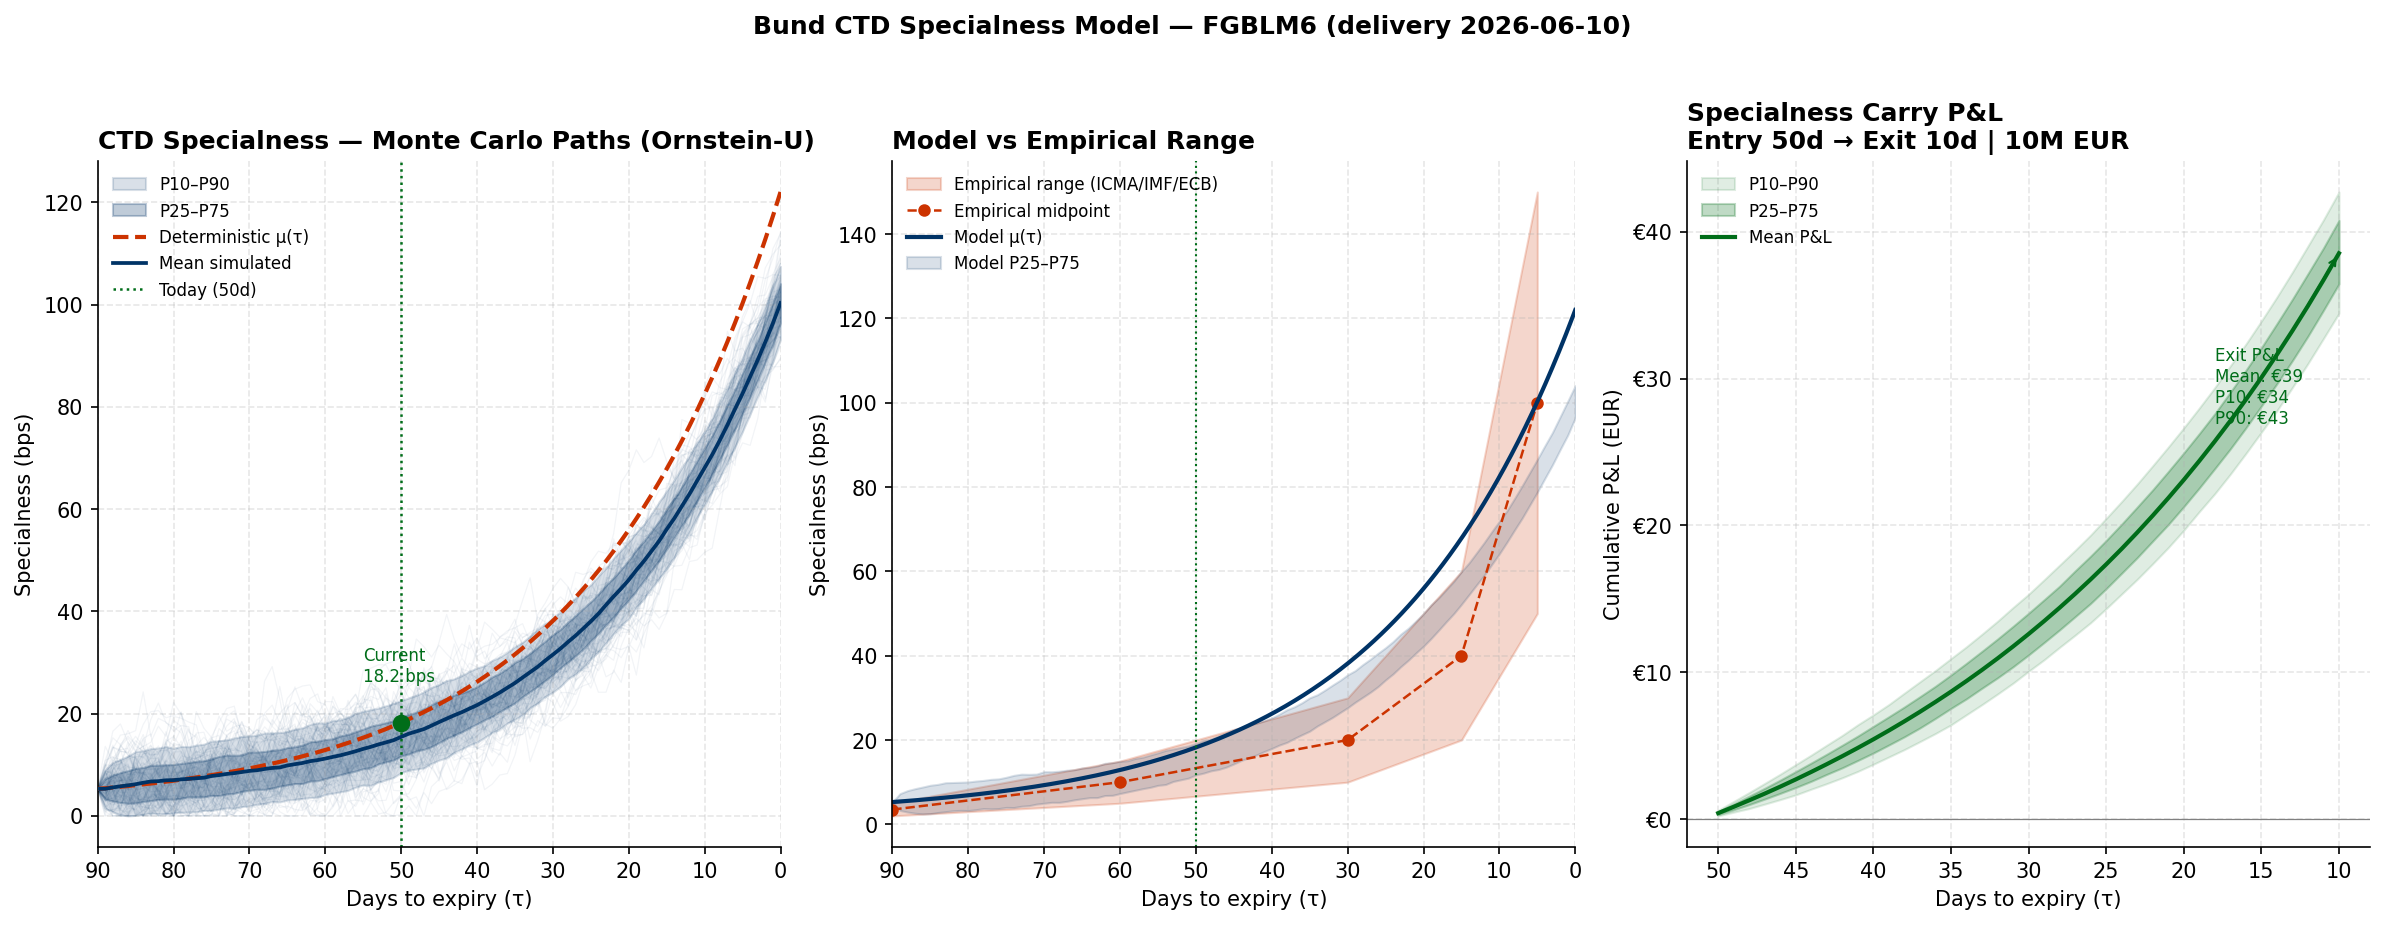


Trade Summary : Specialness Carry
Entry       : 50d to expiry
Exit        : 10d to expiry
Holding     : 40 days
Notional    : EUR 10,000,000
DV01 proxy  : EUR 5,998 per bp
Mean P&L    : EUR 39
P10 P&L     : EUR 34
P90 P&L     : EUR 43


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), dpi=150)


# Panel 1: Monte Carlo fan chart

ax1 = axes[0]

# Plot subset of individual paths
for i in range(0, N_PATHS, max(1, N_PATHS // 80)):
    ax1.plot(dte_axis, paths[i], color='#003366', alpha=0.05, linewidth=0.6)

# Confidence bands
ax1.fill_between(dte_axis, p10_path, p90_path, alpha=0.15, color='#003366', label='P10–P90')
ax1.fill_between(dte_axis, p25_path, p75_path, alpha=0.25, color='#003366', label='P25–P75')

# Deterministic + mean simulated
mu_plot = np.array([mu_specialness_bps(t) for t in dte_axis])
ax1.plot(dte_axis, mu_plot, color='#CC3300', linewidth=2.0, linestyle='--', label='Deterministic μ(τ)', zorder=5)
ax1.plot(dte_axis, mean_path, color='#003366', linewidth=1.8, label='Mean simulated', zorder=6)

# Today marker
current_bps = float(mu_specialness_bps(CURRENT_DTE))
ax1.axvline(CURRENT_DTE, color='#006D19', linewidth=1.2, linestyle=':', label=f'Today ({CURRENT_DTE}d)')
ax1.scatter([CURRENT_DTE], [current_bps], color='#006D19', s=55, zorder=7)
ax1.annotate(f'Current\n{current_bps:.1f} bps',
             xy=(CURRENT_DTE, current_bps),
             xytext=(CURRENT_DTE + 5, current_bps + 8),
             fontsize=8, color='#006D19')

ax1.set_xlabel('Days to expiry (τ)')
ax1.set_ylabel('Specialness (bps)')
ax1.set_title('CTD Specialness — Monte Carlo Paths (Ornstein-U)', fontweight='bold', loc='left')
ax1.legend(frameon=False, fontsize=8)
ax1.invert_xaxis()
ax1.set_xlim(90, 0)


# Panel 2: Model vs empirical bands

ax2 = axes[1]

# Empirical ranges (literature-based anchors)
emp_dte  = np.array([90, 60, 30, 15, 5])
emp_low  = np.array([2, 5, 10, 20, 50], dtype=float)
emp_high = np.array([5, 15, 30, 60, 150], dtype=float)
emp_mid  = (emp_low + emp_high) / 2

ax2.fill_between(emp_dte, emp_low, emp_high, alpha=0.20, color='#CC3300',
                 label='Empirical range (ICMA/IMF/ECB)')
ax2.plot(emp_dte, emp_mid, 'o--', color='#CC3300', linewidth=1.2, markersize=5,
         label='Empirical midpoint')

# Model deterministic + IQR
tau_plot = np.linspace(90, 0, 300)
ax2.plot(tau_plot, [mu_specialness_bps(t) for t in tau_plot],
         color='#003366', linewidth=2.0, label='Model μ(τ)')
ax2.fill_between(dte_axis, p25_path, p75_path, alpha=0.15, color='#003366', label='Model P25–P75')

ax2.axvline(CURRENT_DTE, color='#006D19', linewidth=1.0, linestyle=':')
ax2.set_xlabel('Days to expiry (τ)')
ax2.set_ylabel('Specialness (bps)')
ax2.set_title('Model vs Empirical Range', fontweight='bold', loc='left')
ax2.legend(frameon=False, fontsize=8)
ax2.invert_xaxis()
ax2.set_xlim(90, 0)


# Panel 3: Carry P&L from specialness

ax3 = axes[2]

ENTRY_DTE = CURRENT_DTE
EXIT_DTE = 10
NOTIONAL_PNL = 10_000_000

CTD_DURATION = 6.207 # Real CTD Data
CTD_PRICE = 96.626 # Real CTD Data
DV01_EUR_PER_BP = CTD_DURATION * (CTD_PRICE / 100.0) * NOTIONAL_PNL * 1e-4  # EUR/bp
CASH_VALUE = NOTIONAL * (CTD_PRICE / 100)


# Approach chosen : Daily carry from specialness (in bps) = Specialness (bps) ​× (Notional×P​/100)/10000 ​× 1/360

pnl_paths = np.zeros_like(paths)

for step in range(1, N_STEPS + 1):
    dte = TAU_START - step
    if EXIT_DTE <= dte <= ENTRY_DTE:
        daily_carry = paths[:, step] * (CASH_VALUE / 10000) / 360
        pnl_paths[:, step] = pnl_paths[:, step - 1] + daily_carry
    else:
        pnl_paths[:, step] = pnl_paths[:, step - 1]

entry_idx = TAU_START - ENTRY_DTE
exit_idx = TAU_START - EXIT_DTE

trade_dte = dte_axis[entry_idx:exit_idx + 1]
pnl_mean = pnl_paths.mean(axis=0)[entry_idx:exit_idx + 1]
pnl_p10  = np.percentile(pnl_paths, 10, axis=0)[entry_idx:exit_idx + 1]
pnl_p25  = np.percentile(pnl_paths, 25, axis=0)[entry_idx:exit_idx + 1]
pnl_p75  = np.percentile(pnl_paths, 75, axis=0)[entry_idx:exit_idx + 1]
pnl_p90  = np.percentile(pnl_paths, 90, axis=0)[entry_idx:exit_idx + 1]

ax3.fill_between(trade_dte, pnl_p10, pnl_p90, alpha=0.12, color='#006D19', label='P10–P90')
ax3.fill_between(trade_dte, pnl_p25, pnl_p75, alpha=0.25, color='#006D19', label='P25–P75')
ax3.plot(trade_dte, pnl_mean, color='#006D19', linewidth=2.0, label='Mean P&L')

ax3.axhline(0, color='gray', linewidth=0.6)
ax3.set_xlabel('Days to expiry (τ)')
ax3.set_ylabel('Cumulative P&L (EUR)')
ax3.set_title(f'Specialness Carry P&L\nEntry {ENTRY_DTE}d → Exit {EXIT_DTE}d | {NOTIONAL_PNL/1e6:.0f}M EUR',
              fontweight='bold', loc='left')
ax3.legend(frameon=False, fontsize=8)
ax3.invert_xaxis()
ax3.set_xlim(ENTRY_DTE + 2, EXIT_DTE - 2)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

final_mean = pnl_mean[-1]
final_p10 = pnl_p10[-1]
final_p90 = pnl_p90[-1]

ax3.annotate(
    f'Exit P&L\nMean: €{final_mean:,.0f}\nP10: €{final_p10:,.0f}\nP90: €{final_p90:,.0f}',
    xy=(EXIT_DTE, final_mean),
    xytext=(EXIT_DTE + 8, final_mean * 0.7 if final_mean > 0 else final_mean * 1.3),
    fontsize=8, color='#006D19',
    arrowprops=dict(arrowstyle='->', color='#006D19')
)

plt.suptitle(
    f'Bund CTD Specialness Model — {FUTURE_CONTRACT} (delivery {DELIVERY_DATE.date()})',
    fontweight='bold', fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

print("\nTrade Summary : Specialness Carry")
print(f"Entry       : {ENTRY_DTE}d to expiry")
print(f"Exit        : {EXIT_DTE}d to expiry")
print(f"Holding     : {ENTRY_DTE - EXIT_DTE} days")
print(f"Notional    : EUR {NOTIONAL_PNL:,.0f}")
print(f"DV01 proxy  : EUR {DV01_EUR_PER_BP:,.0f} per bp")
print(f"Mean P&L    : EUR {final_mean:,.0f}")
print(f"P10 P&L     : EUR {final_p10:,.0f}")
print(f"P90 P&L     : EUR {final_p90:,.0f}")

---

### II.3. Conclusion on the Specialness Model — Results & Trading Implications

#### • Model output at current date (50d to expiry)

| Metric | Value |
|---|---|
| Current specialness estimate | **18.2 bps** |
| Deterministic path at delivery | **122.0 bps** |
| Mean simulated at delivery | **~100.4 bps** |
| P10 at delivery | **93.1 bps** |
| P90 at delivery | **107.9 bps** |

The model confirms the expected convex specialness profile: a gradual
increase from ~18 bps at 50d to a sharp acceleration in the final
delivery window, consistent with the empirical term structure documented
in the literature (ICMA / IMF / ECB).

#### • Trade mechanics — specialness carry

The strategy is framed as a **CTD repo carry trade**:

- source the CTD bond in the cash market,
- repo it out at the special rate, earning the GC/special spread,
- fund the long position at GC.

Daily P&L is computed as the specialness earned on the **cash value** of
the position — the economically correct base since repo interest accrues
on the amount of cash exchanged, not on the nominal:

$$\text{Daily P\&L} = S_t \times \frac{N \times \frac{P}{100}}{10{,}000} \times \frac{1}{360}$$

where:
- $S_t$ = modeled specialness in bps,
- $N$ = notional (EUR 10,000,000),
- $P$ = CTD clean price (96.626),
- $\frac{1}{360}$ = ACT/360 repo day count convention.

This gives a cash value of **€9,662,600** on which specialness accrues daily.

#### • Simulated trade results (Entry 50d → Exit 10d, €10M notional)

| Metric | Value |
|---|---|
| Holding period | **40 days** |
| Notional | **€10,000,000** |
| Cash value (repo base) | **€9,662,600** |
| Mean cumulative P&L | **€39** |
| P10 (adverse scenario) | **€34** |
| P90 (favourable scenario) | **€43** |
| P&L dispersion (P90 − P10) | **€9** |

#### • Interpreting the P&L magnitude

The P&L of ~€39 on €10M notional over 40 days reflects the true
economics of a **pure repo specialness carry trade at the 50d horizon**:
at ~18 bps of current specialness, the daily carry is approximately:

$$18 \times \frac{9{,}662{,}600}{10{,}000} \times \frac{1}{360} \approx \text{€}4.8 \text{ / day}$$

This is intentionally small — specialness carry is not a standalone
high-return strategy. In practice, it is one component of a broader
**basis trade** (long cash CTD / short futures), where the specialness
carry offsets part of the negative carry from the futures leg.

The value of this model lies not in the absolute P&L, but in the
**convex payoff profile**: carry accelerates non-linearly as expiry
approaches, which is exactly what a repo desk exploits by entering
the position early and unwinding before the final squeeze window.

The tight P10–P90 band (€9 dispersion) reflects OU mean reversion
around the rising deterministic path — the trade is low-volatility
by construction until the final delivery squeeze window.

#### • Why exit at 10d rather than at delivery?

1. **Delivery squeeze risk** rises sharply in the final days —
   specialness can spike to 50–150 bps intraday (2022 Bund squeeze).
2. **Execution risk** increases near expiry (CF-adjusted hedging,
   tail management — Hill, ICMA 2022).
3. The model's OU dynamics become less reliable in the final window
   where jump-diffusion effects dominate.

#### • Key limitations

- **No live special repo data:** specialness is modelled, not observed.
  In production, live special rates from BrokerTec/MTS or Bloomberg
  RRRA would replace the synthetic OU process entirely.
- **Simplified carry in Part I:** coupon cash between today and delivery
  set to zero; accrued at delivery approximated by current accrued.
- **Single-factor OU model:** regime shifts (ECB securities lending,
  PSPP scarcity effects, stress episodes) are not captured.
- **Static CTD assumption:** no switch modelled — stress-tested
  separately in Part IV.
- **Pure repo carry framing:** this P&L does not include the futures
  leg of a full basis trade, nor transaction costs or haircuts.

---
---

## III. Model Risk & Sensitivity Analysis

#### • Objective

This section evaluates how robust the CTD and specialness conclusions are to key model inputs.  
Given the use of public/proxy data, sensitivity analysis is essential to avoid overconfidence in point estimates.

We run two complementary diagnostics:

1. **CTD sensitivity grid**  
   We vary:
   - futures price $F$ around the observed level,
   - funding rate proxy $r_{GC}$ around baseline assumptions,  
   and recompute net basis for all deliverables to detect potential CTD switches.

2. **Specialness model parameter sensitivity**  
   We vary Ornstein-Uhlenbeck parameters ($\alpha$, $\beta$, $\kappa$, $\sigma$) and evaluate the impact on:
   - expected carry P\&L,
   - downside (P10),
   - upside (P90).

#### • Why this matters for a repo desk

A repo/specialness trade is highly sensitive to:
- relative-value inputs (cash-futures basis),
- funding conditions,
- model dynamics near expiry.

The goal is not to “prove” a single forecast, but to quantify how conclusions change under plausible market regimes.

---

### III.1. CTD sensitivity

CTD Sensitivity — Key Takeaways
- Dominant CTD ISIN: DE000BU2Z049 (100.0% of scenarios)
- Min CTD vs runner-up gap: 0.0150
- Median gap: 0.0150
- Scenario count: 99


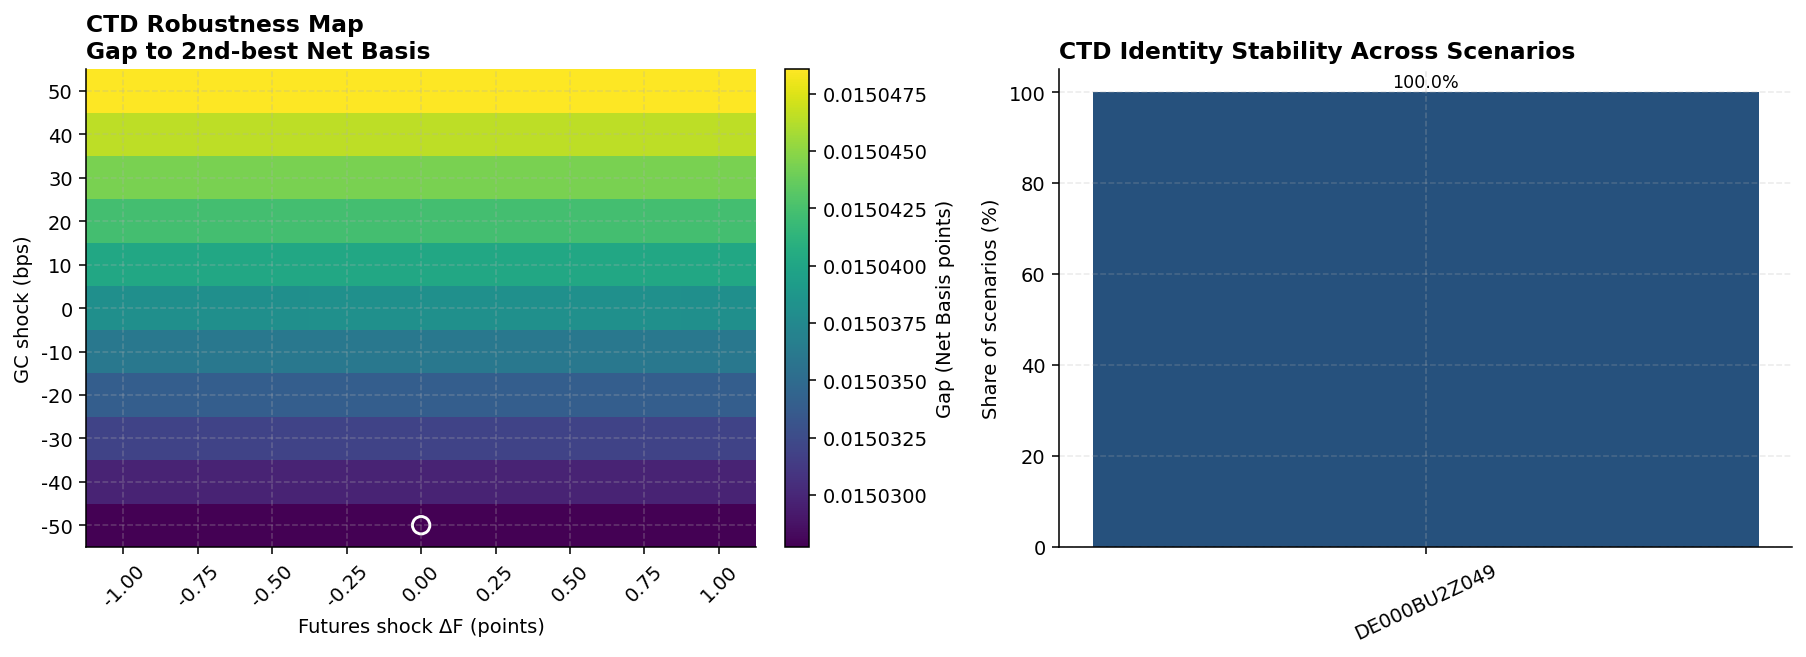

In [ ]:
t = DAYS_TO_EXPIRY / 360.0
f_shocks = np.arange(-1.00, 1.01, 0.25)
gc_shocks_bps = np.arange(-50, 51, 10)

def compute_net_basis_row(row, F_input, gc_rate_input):
    P = row["price"]
    AI0 = row["accrued"]
    CF = row["cf"]
    dirty0 = P + AI0
    carry = -(dirty0 * gc_rate_input * t)   # cash_coupon =0
    gross_basis = P - F_input * CF
    return gross_basis - carry

records = []
for dF in f_shocks:
    for dGC in gc_shocks_bps:
        F_scn = F_MKT + dF
        gc_scn = GC_RATE + dGC / 10000.0

        tmp = df.copy()
        tmp["nb"] = tmp.apply(lambda r: compute_net_basis_row(r, F_scn, gc_scn), axis=1)
        s = tmp.sort_values("nb")

        ctd = s.iloc[0]
        runner = s.iloc[1]
        gap = float(runner["nb"] - ctd["nb"])

        records.append({
            "dF": dF,
            "dGC_bps": dGC,
            "CTD_ISIN": ctd["isin"],
            "CTD_gap": gap
        })

df_sens = pd.DataFrame(records)

# KPI summary
n = len(df_sens)
top = df_sens["CTD_ISIN"].value_counts().rename_axis("ISIN").reset_index(name="n")
top["share_%"] = (100 * top["n"] / n).round(1)

main_isin = top.iloc[0, 0]
main_share = top.iloc[0, 2]
min_gap = df_sens["CTD_gap"].min()
med_gap = df_sens["CTD_gap"].median()

print("CTD Sensitivity — Key Takeaways")
print(f"- Dominant CTD ISIN: {main_isin} ({main_share:.1f}% of scenarios)")
print(f"- Min CTD vs runner-up gap: {min_gap:.4f}")
print(f"- Median gap: {med_gap:.4f}")
print(f"- Scenario count: {n}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), dpi=140)

# Panel 1 : Heatmap of CTD gap
ax = axes[0]
gap_pivot = df_sens.pivot(index="dGC_bps", columns="dF", values="CTD_gap")
im = ax.imshow(
    gap_pivot.values,
    aspect="auto",
    origin="lower",
    cmap="viridis"
)
ax.set_title("CTD Robustness Map\nGap to 2nd-best Net Basis", loc="left", fontweight="bold")
ax.set_xlabel("Futures shock ΔF (points)")
ax.set_ylabel("GC shock (bps)")
ax.set_xticks(range(len(gap_pivot.columns)))
ax.set_xticklabels([f"{x:.2f}" for x in gap_pivot.columns], rotation=45)
ax.set_yticks(range(len(gap_pivot.index)))
ax.set_yticklabels([f"{int(y)}" for y in gap_pivot.index])
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Gap (Net Basis points)")

min_idx = np.unravel_index(np.argmin(gap_pivot.values), gap_pivot.values.shape)
ax.scatter(min_idx[1], min_idx[0], s=80, facecolors='none', edgecolors='white', linewidth=1.5)

# Panel 2 : Stability bar chart
ax2 = axes[1]
ax2.bar(top["ISIN"], top["share_%"], color="#003366", alpha=0.85)
ax2.set_title("CTD Identity Stability Across Scenarios", loc="left", fontweight="bold")
ax2.set_ylabel("Share of scenarios (%)")
ax2.set_ylim(0, 105)
ax2.grid(axis="y", alpha=0.25, linestyle="--")
for i, v in enumerate(top["share_%"]):
    ax2.text(i, v + 1.2, f"{v:.1f}%", ha="center", fontsize=9)
ax2.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

#### Results — CTD sensitivity to futures and GC shocks

The CTD sensitivity grid was run over 99 scenarios:

- Futures shock: $\Delta F \in [-1.00, +1.00]$ points,
- GC shock: $\Delta GC \in [-50, +50]$ bps.

##### • Main Findings

- **Dominant CTD ISIN:** `DE000BU2Z049` (**100.0%** of scenarios),
- **Minimum CTD vs runner-up net basis gap:** **0.0150**,
- **Median CTD vs runner-up net basis gap:** **0.0150**.

##### • Interpretation

The CTD identity is highly stable under reasonable parallel shocks to futures and GC assumptions.  
No switch is observed within the tested range.

However, the gap to the runner-up remains small (~0.015 net basis points), which means:

1. **robust under broad macro shocks** (parallel $F$ / GC moves), but
2. **potentially sensitive to idiosyncratic relative-value moves** between nearby deliverables (same maturity bucket).

In practice, this suggests that day-to-day CTD monitoring should focus more on:
- relative repricing between the two Feb-35 lines,
- bond-specific repo richness/availability,
- micro-liquidity distortions,
rather than only on parallel futures or funding shocks.

---

### III.2. Ornstein-Uhlenbeck parameter sensitivity (specialness + carry P&L)

Ornstein-Uhlenbeck Parameter Sensitivity — Summary Table


,Scenario,alpha_bps,beta,gamma_bps,kappa,sigma_bps,S_now_mean_bps,S_deliv_mean_bps,PnL_mean_EUR,PnL_P10_EUR,PnL_P90_EUR,PnL_std_EUR
0,BASE,120.0,0.040,2.0,0.15,3.0,15.45,100.24,3862.0,3455.0,4267.0,318.0
1,alpha -20%,96.0,0.040,2.0,0.15,3.0,12.83,80.37,3125.0,2705.0,3510.0,311.0
2,alpha +20%,144.0,0.040,2.0,0.15,3.0,18.06,119.52,4586.0,4178.0,4985.0,318.0
3,beta -20%,120.0,0.032,2.0,0.15,3.0,22.33,103.76,4811.0,4394.0,5226.0,318.0
4,beta +20%,120.0,0.048,2.0,0.15,3.0,11.02,96.84,3123.0,2722.0,3531.0,311.0
5,kappa -20%,120.0,0.040,2.0,0.12,3.0,14.68,95.09,3674.0,3165.0,4179.0,395.0
6,kappa +20%,120.0,0.040,2.0,0.18,3.0,15.77,103.51,3982.0,3637.0,4320.0,267.0
7,sigma -20%,120.0,0.040,2.0,0.15,2.4,15.43,100.15,3854.0,3529.0,4180.0,256.0
8,sigma +20%,120.0,0.040,2.0,0.15,3.6,15.51,100.24,3858.0,3355.0,4355.0,386.0


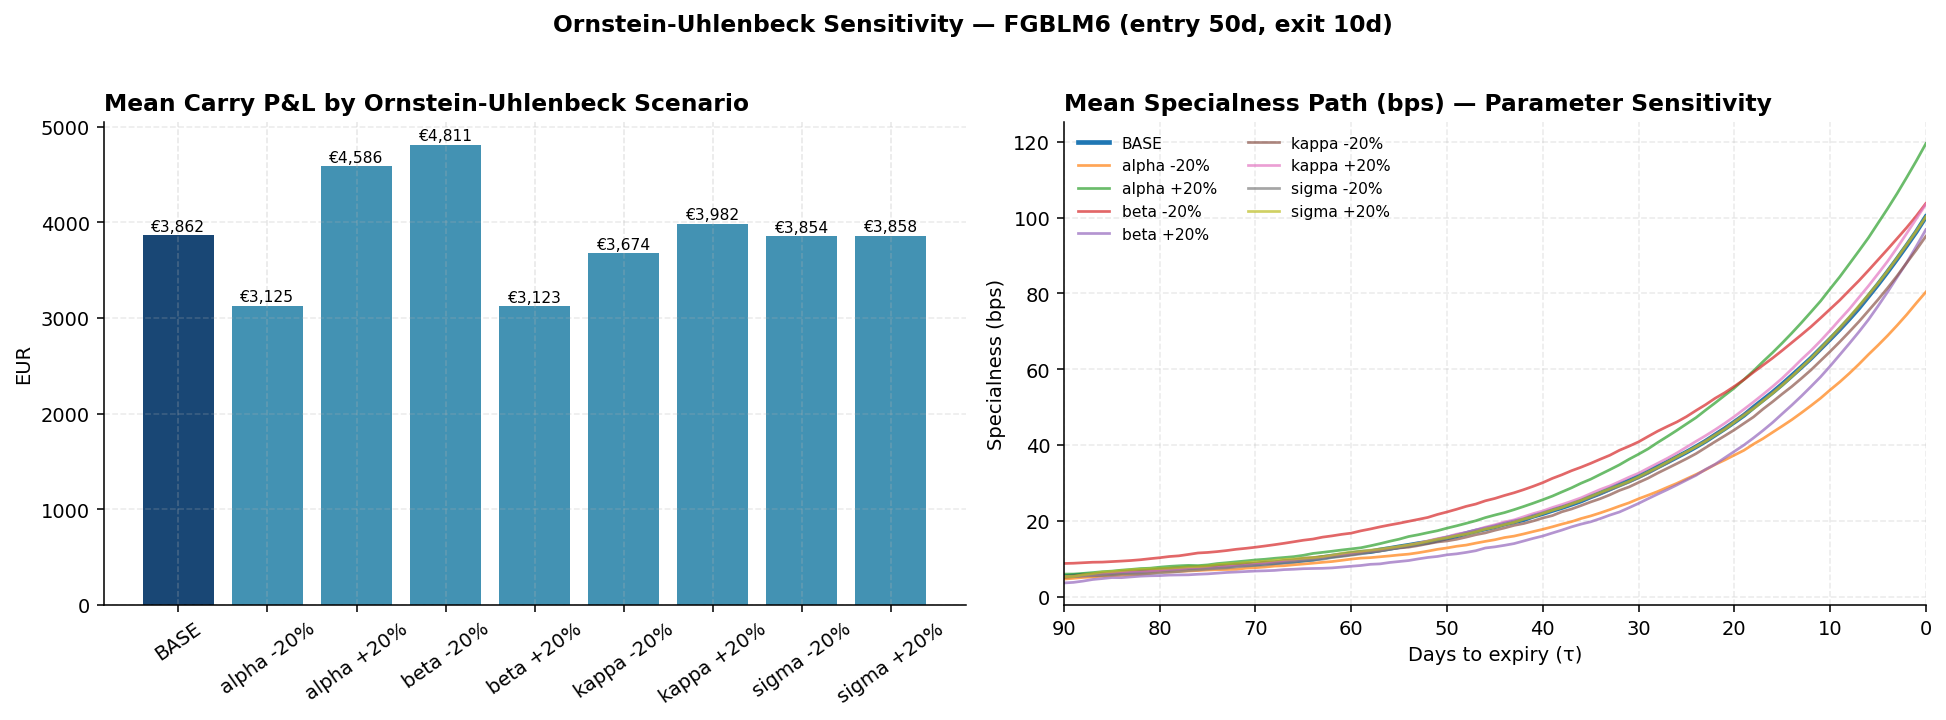


P&L impact vs BASE (sorted):


,Scenario,PnL_mean_EUR,Delta_vs_BASE_EUR
3,beta -20%,4811.0,949.0
2,alpha +20%,4586.0,724.0
6,kappa +20%,3982.0,120.0
0,BASE,3862.0,0.0
8,sigma +20%,3858.0,-4.0
7,sigma -20%,3854.0,-8.0
5,kappa -20%,3674.0,-188.0
1,alpha -20%,3125.0,-737.0
4,beta +20%,3123.0,-739.0


In [ ]:
np.random.seed(42)

TAU_START = 90
N_STEPS = TAU_START
DT = 1.0
N_PATHS = 1500

ENTRY_DTE = int(DAYS_TO_EXPIRY)   # 50 in our case
EXIT_DTE = 10
NOTIONAL_PNL = 10_000_000

# Same approach as previous section for Daily Carry : Daily P&L=Specialness (bps) ​× (Notional×P​/100)/10000 ​× 1/360
CTD_DURATION = 6.207 # real data
CTD_PRICE = 96.626 # real data
DV01_EUR_PER_BP = CTD_DURATION * (CTD_PRICE / 100.0) * NOTIONAL_PNL * 1e-4  # EUR per bp
CASH_VALUE = NOTIONAL_PNL * (CTD_PRICE / 100)

def mu_bps(tau, alpha_bps, beta, gamma_bps):
    return gamma_bps + alpha_bps * np.exp(-beta * tau)

def run_ou_sim(alpha_bps, beta, gamma_bps, kappa, sigma_bps,
               n_paths=N_PATHS, tau_start=TAU_START, dt=DT):
    """
    Returns:
        paths: shape (n_paths, tau_start+1), in bps
        dte_axis: shape (tau_start+1), descending from tau_start to 0
    """
    paths = np.zeros((n_paths, tau_start + 1))
    paths[:, 0] = mu_bps(tau_start, alpha_bps, beta, gamma_bps)

    for step in range(1, tau_start + 1):
        tau_current = tau_start - step
        mu_t = mu_bps(tau_current, alpha_bps, beta, gamma_bps)
        dW = np.random.normal(0.0, np.sqrt(dt), size=n_paths)

        paths[:, step] = (
            paths[:, step - 1]
            + kappa * (mu_t - paths[:, step - 1]) * dt
            + sigma_bps * dW
        )
        paths[:, step] = np.maximum(paths[:, step], 0.0)

    dte_axis = np.array([tau_start - s for s in range(tau_start + 1)])
    return paths, dte_axis

def pnl_from_paths(paths, dte_axis, entry_dte, exit_dte, CASH_VALUE):
    pnl_paths = np.zeros_like(paths)
    tau_start = int(dte_axis.max())

    for step in range(1, paths.shape[1]):
        dte = tau_start - step
        if exit_dte <= dte <= entry_dte:
            daily_carry = paths[:, step] * (CASH_VALUE / 10000) / 360
            pnl_paths[:, step] = pnl_paths[:, step - 1] + daily_carry
        else:
            pnl_paths[:, step] = pnl_paths[:, step - 1]

    exit_idx = tau_start - exit_dte
    final_pnl = pnl_paths[:, exit_idx]
    return final_pnl, pnl_paths

# Scenario grid: one-at-a-time sensitivity around baseline
param_sets = [
    ("BASE",       ALPHA_BPS, BETA, GAMMA_BPS, KAPPA, SIGMA_BPS),

    ("alpha -20%", ALPHA_BPS * 0.8, BETA, GAMMA_BPS, KAPPA, SIGMA_BPS),
    ("alpha +20%", ALPHA_BPS * 1.2, BETA, GAMMA_BPS, KAPPA, SIGMA_BPS),

    ("beta -20%",  ALPHA_BPS, BETA * 0.8, GAMMA_BPS, KAPPA, SIGMA_BPS),
    ("beta +20%",  ALPHA_BPS, BETA * 1.2, GAMMA_BPS, KAPPA, SIGMA_BPS),

    ("kappa -20%", ALPHA_BPS, BETA, GAMMA_BPS, KAPPA * 0.8, SIGMA_BPS),
    ("kappa +20%", ALPHA_BPS, BETA, GAMMA_BPS, KAPPA * 1.2, SIGMA_BPS),

    ("sigma -20%", ALPHA_BPS, BETA, GAMMA_BPS, KAPPA, SIGMA_BPS * 0.8),
    ("sigma +20%", ALPHA_BPS, BETA, GAMMA_BPS, KAPPA, SIGMA_BPS * 1.2),
]

rows = []
all_mean_paths = {}

for name, a, b, g, k, s in param_sets:
    paths_s, dte_axis_s = run_ou_sim(a, b, g, k, s)
    final_pnl, pnl_paths = pnl_from_paths(paths_s, dte_axis_s, ENTRY_DTE, EXIT_DTE, CASH_VALUE)

    # Delivery and current checkpoints
    idx_0 = TAU_START - 0
    idx_current = TAU_START - ENTRY_DTE

    mean_path = paths_s.mean(axis=0)
    all_mean_paths[name] = mean_path

    rows.append({
        "Scenario": name,
        "alpha_bps": round(a, 2),
        "beta": round(b, 4),
        "gamma_bps": round(g, 2),
        "kappa": round(k, 4),
        "sigma_bps": round(s, 2),

        "S_now_mean_bps": round(mean_path[idx_current], 2),
        "S_deliv_mean_bps": round(mean_path[idx_0], 2),

        "PnL_mean_EUR": round(final_pnl.mean(), 0),
        "PnL_P10_EUR": round(np.percentile(final_pnl, 10), 0),
        "PnL_P90_EUR": round(np.percentile(final_pnl, 90), 0),
        "PnL_std_EUR": round(final_pnl.std(), 0),
    })

df_ou_sens = pd.DataFrame(rows)

# Sort for readability
order = ["BASE", "alpha -20%", "alpha +20%", "beta -20%", "beta +20%",
         "kappa -20%", "kappa +20%", "sigma -20%", "sigma +20%"]
df_ou_sens["order"] = df_ou_sens["Scenario"].map({k: i for i, k in enumerate(order)})
df_ou_sens = df_ou_sens.sort_values("order").drop(columns=["order"])

print("Ornstein-Uhlenbeck Parameter Sensitivity — Summary Table")
display(df_ou_sens)

# Panel 1: Mean P&L by scenario 
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=140)

ax = axes[0]
plot_df = df_ou_sens.copy()
colors = ["#003366" if s == "BASE" else "#2E86AB" for s in plot_df["Scenario"]]
ax.bar(plot_df["Scenario"], plot_df["PnL_mean_EUR"], color=colors, alpha=0.9)
ax.set_title("Mean Carry P&L by Ornstein-Uhlenbeck Scenario", loc="left", fontweight="bold")
ax.set_ylabel("EUR")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.25, linestyle="--")
for i, v in enumerate(plot_df["PnL_mean_EUR"]):
    ax.text(i, v + (0.01 * max(plot_df["PnL_mean_EUR"])), f"€{v:,.0f}", ha="center", fontsize=8)

# Panel 2: Mean specialness term structures
ax2 = axes[1]
for name in order:
    series = all_mean_paths[name]
    lw = 2.4 if name == "BASE" else 1.4
    alpha = 1.0 if name == "BASE" else 0.7
    ax2.plot(dte_axis_s, series, linewidth=lw, alpha=alpha, label=name)

ax2.set_title("Mean Specialness Path (bps) — Parameter Sensitivity", loc="left", fontweight="bold")
ax2.set_xlabel("Days to expiry (τ)")
ax2.set_ylabel("Specialness (bps)")
ax2.invert_xaxis()
ax2.set_xlim(90, 0)
ax2.grid(alpha=0.25, linestyle="--")
ax2.legend(frameon=False, fontsize=8, ncol=2)

plt.suptitle(
    f"Ornstein-Uhlenbeck Sensitivity — {FUTURE_CONTRACT} (entry {ENTRY_DTE}d, exit {EXIT_DTE}d)",
    y=1.02, fontweight="bold"
)
plt.tight_layout()
plt.show()

# Compact ranking (impact vs base)
base_mean = float(df_ou_sens.loc[df_ou_sens["Scenario"] == "BASE", "PnL_mean_EUR"].iloc[0])
impact = df_ou_sens[["Scenario", "PnL_mean_EUR"]].copy()
impact["Delta_vs_BASE_EUR"] = impact["PnL_mean_EUR"] - base_mean
impact = impact.sort_values("Delta_vs_BASE_EUR", ascending=False)

print("\nP&L impact vs BASE:")
display(impact)

#### Results — Ornstein-Uhlenbeck parameter sensitivity (entry 50d, exit 10d)

We run one-at-a-time parameter shocks around the baseline Ornstein-Uhlenbeck 
setup and compare carry P&L outcomes. All values reflect the corrected 
repo carry formula: $S_t \times \frac{N \times P/100}{10{,}000} \times \frac{1}{360}$,
applied on a cash value of **€9,662,600** (€10M notional × 96.626% price).

##### • Baseline reference

- Mean P&L: **€3,862**
- P10: **€3,455** | P90: **€4,267** | Std dev: **€318**
- Mean specialness: **15.45 bps at 50d**, **100.24 bps at delivery**

##### • Main findings

1. **Most impactful parameters: $\alpha$ and $\beta$**

   These two parameters govern the **term structure shape** and dominate
   the economics of the trade:

   | Scenario | Mean P&L | Δ vs BASE |
   |---|---|---|
   | $\beta$ −20% | **€4,811** | **+€949** |
   | $\alpha$ +20% | **€4,586** | **+€724** |
   | $\alpha$ −20% | **€3,125** | **−€737** |
   | $\beta$ +20% | **€3,123** | **−€739** |

   - A **lower $\beta$** (slower acceleration speed) keeps specialness
     elevated for longer during the 50d–10d holding window — more
     carry is collected before the final squeeze.
   - A **higher $\alpha$** (larger peak component) lifts the entire
     term structure — higher carry at every day of the holding period.
   - Interpretation: trade value is primarily driven by the **level and
     steepening speed of the specialness term structure**, not by noise.

2. **$\kappa$ has a secondary but measurable effect**

   - $\kappa$ +20%: **€3,982** (+€120 vs base)
   - $\kappa$ −20%: **€3,674** (−€188 vs base)

   Faster mean reversion pulls paths more tightly toward the rising
   deterministic mean — a modest improvement in expected carry.
   Conversely, slower reversion allows paths to drift further below
   the mean during the early holding period, reducing carry collected.
   Note the asymmetry: $\kappa$ +20% widens the std dev slightly
   (€267 vs €318 base) while $\kappa$ −20% widens it materially
   (€395) — lower reversion leaves more path uncertainty.

3. **$\sigma$ has negligible effect on mean P&L**

   - $\sigma$ −20%: **€3,854** (−€8 vs base)
   - $\sigma$ +20%: **€3,858** (−€4 vs base)

   As expected from OU theory, daily noise averages out over the
   40-day holding period — mean P&L is unaffected. However,
   std dev widens from €256 ($\sigma$ −20%) to €386 ($\sigma$ +20%),
   confirming that volatility assumptions matter exclusively for
   **risk limits and P10/P90 scenario sizing**.

##### • Practical interpretation for desk usage

- The strategy is fundamentally a **term-structure carry trade**
  ($\alpha$, $\beta$-driven) — calibration of $\mu(\tau)$ is the
  primary model-risk driver, with a potential P&L swing of
  ±€740–€950 under ±20% parameter shocks.
- $\kappa$ calibration matters moderately — a poorly estimated
  mean-reversion speed can bias expected carry by up to €188.
- $\sigma$ assumptions matter for **VaR and risk limits** only —
  the P10/P90 band widens from €651 ($\sigma$ −20%) to
  €1,000 ($\sigma$ +20%).
- At the base level, the trade generates **€3,862 on €10M notional**
  over 40 days — equivalent to ~**1.5 bps annualised return on
  cash deployed**, consistent with the thin but predictable nature
  of a pure repo specialness carry strategy.

##### • Humble model-risk note

These results are based on a synthetic Ornstein-Uhlenbeck framework
calibrated to public stylized ranges, not live special-repo time series.
The P&L figures should be read as **order-of-magnitude scenario
benchmarks**, not executable forecasts. In production, the OU parameters
would be re-estimated daily from live BrokerTec/MTS special repo prints,
and the carry formula would use exact repo cash flow schedules rather
than a continuous ACT/360 approximation.

---
---

## IV. CTD Switch Stress Test

#### • Objective

Even when the base-case CTD appears stable, a repo desk must assess **switch risk** under non-parallel shocks.  
This section stress-tests whether the current CTD remains optimal when relative-value conditions move abruptly.

#### • Stress design

We define three stylized scenarios:

1. **Bull rally / basis compression**  
   Futures and cash reprice higher; relative basis can compress.

2. **Bear sell-off / basis widening**  
   Futures and cash reprice lower; relative basis can widen.

3. **Idiosyncratic CTD micro-structure shock**  
   The current runner-up bond cheapens versus the CTD (liquidity/flow/repo effects), creating a potential CTD switch.

For each scenario, we recompute net basis across the basket and compare:
- CTD identity,
- CTD-vs-runner-up gap,
- switch flag (yes/no).

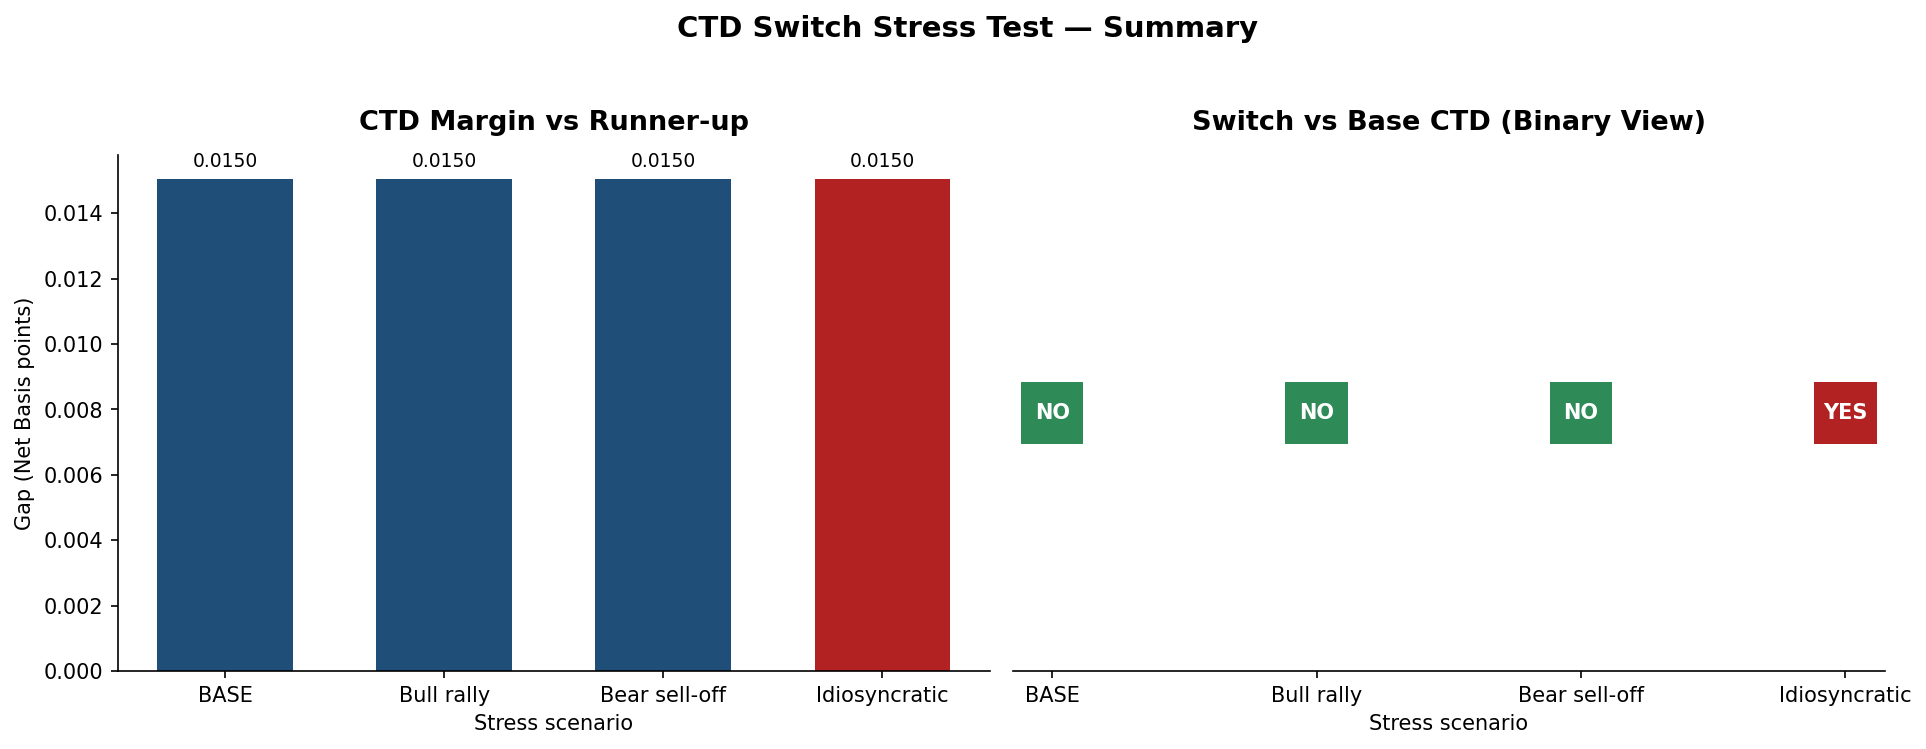

,Scenario,CTD_ISIN,Runner_ISIN,CTD_NetBasis,Gap_to_Runner,Switch_vs_Base
0,BASE,DE000BU2Z049,DE000BU3Z047,0.1973,0.0150,NO
1,Bull rally / basis compression,DE000BU2Z049,DE000BU3Z047,0.2040,0.0150,NO
2,Bear sell-off / basis widening,DE000BU2Z049,DE000BU3Z047,0.1902,0.0150,NO
3,Idiosyncratic runner cheapening,DE000BU3Z047,DE000BU2Z049,0.1823,0.0150,YES


In [ ]:
t = DAYS_TO_EXPIRY / 360.0

def net_basis_first_pass(row, F_input, gc_rate_input):
    P = row["price"]
    AI0 = row["accrued"]
    CF = row["cf"]
    dirty0 = P + AI0
    carry = -(dirty0 * gc_rate_input * t)   # cash_coupon=0
    gross_basis = P - F_input * CF
    return gross_basis - carry

base = df.copy()
base["net_basis"] = base.apply(lambda r: net_basis_first_pass(r, F_MKT, GC_RATE), axis=1)
base = base.sort_values("net_basis")
base_ctd_isin = base.iloc[0]["isin"]
base_runner_isin = base.iloc[1]["isin"]

scenarios = [
    {"Scenario": "BASE", "futures_shift": 0.00, "gc_shift_bps": 0,   "cash_shift_all": 0.00, "idio_moves": {}},
    {"Scenario": "Bull rally / basis compression", "futures_shift": +1.00, "gc_shift_bps": -20, "cash_shift_all": +0.80, "idio_moves": {}},
    {"Scenario": "Bear sell-off / basis widening", "futures_shift": -1.00, "gc_shift_bps": +20, "cash_shift_all": -0.80, "idio_moves": {}},
    {"Scenario": "Idiosyncratic runner cheapening", "futures_shift": 0.00, "gc_shift_bps": 0, "cash_shift_all": 0.00, "idio_moves": {base_runner_isin: -0.03}},
]

rows = []
for scn in scenarios:
    F_scn = F_MKT + scn["futures_shift"]
    gc_scn = GC_RATE + scn["gc_shift_bps"] / 10000.0

    tmp = df.copy()
    tmp["price_scn"] = tmp["price"] + scn["cash_shift_all"]

    for isin_k, px_shift in scn["idio_moves"].items():
        tmp.loc[tmp["isin"] == isin_k, "price_scn"] += px_shift

    def nb_scn(row):
        P = row["price_scn"]
        AI0 = row["accrued"]
        CF = row["cf"]
        dirty0 = P + AI0
        carry = -(dirty0 * gc_scn * t)
        gross_basis = P - F_scn * CF
        return gross_basis - carry

    tmp["net_basis_scn"] = tmp.apply(nb_scn, axis=1)
    srt = tmp.sort_values("net_basis_scn")

    ctd = srt.iloc[0]
    runner = srt.iloc[1]
    gap = float(runner["net_basis_scn"] - ctd["net_basis_scn"])
    switched = int(ctd["isin"] != base_ctd_isin)  # 1 yes, 0 no

    rows.append({
        "Scenario": scn["Scenario"],
        "CTD_ISIN": ctd["isin"],
        "Runner_ISIN": runner["isin"],
        "CTD_NetBasis": float(ctd["net_basis_scn"]),
        "Gap_to_Runner": gap,
        "Switch_num": switched,
        "Switch_vs_Base": "YES" if switched else "NO"
    })

df_switch = pd.DataFrame(rows)

# Labels
short_labels = {
    "BASE": "BASE",
    "Bull rally / basis compression": "Bull rally",
    "Bear sell-off / basis widening": "Bear sell-off",
    "Idiosyncratic runner cheapening": "Idiosyncratic"
}
df_switch["Scenario_short"] = df_switch["Scenario"].map(short_labels)

# Visualization 
plt.style.use("default")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), dpi=150)

# Panel 1: gap bars 
ax = axes[0]
bar_colors = ["#1f4e79" if s == "NO" else "#b22222" for s in df_switch["Switch_vs_Base"]]
bars = ax.bar(df_switch["Scenario_short"], df_switch["Gap_to_Runner"], color=bar_colors, width=0.62)

ax.set_title("CTD Margin vs Runner-up", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Gap (Net Basis points)")
ax.set_xlabel("Stress scenario")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for b, v in zip(bars, df_switch["Gap_to_Runner"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.00025, f"{v:.4f}",
            ha="center", va="bottom", fontsize=9)

# Panel 2: binary switch strip
ax2 = axes[1]
x = np.arange(len(df_switch))
y = np.zeros(len(df_switch)) + 0.5

colors = ["#2e8b57" if v == 0 else "#b22222" for v in df_switch["Switch_num"]]
ax2.scatter(x, y, s=900, c=colors, marker="s", edgecolors="none")

for i, sw in enumerate(df_switch["Switch_vs_Base"]):
    ax2.text(i, 0.5, sw, ha="center", va="center", color="white", fontsize=10, fontweight="bold")

ax2.set_title("Switch vs Base CTD (Binary View)", fontsize=13, fontweight="bold", pad=12)
ax2.set_xticks(x)
ax2.set_xticklabels(df_switch["Scenario_short"])
ax2.set_yticks([])
ax2.set_ylim(0, 1)
ax2.set_xlabel("Stress scenario")
ax2.grid(False)
for side in ["top", "right", "left"]:
    ax2.spines[side].set_visible(False)

# title
fig.suptitle("CTD Switch Stress Test — Summary", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# Compact table
display(
    df_switch[["Scenario", "CTD_ISIN", "Runner_ISIN", "CTD_NetBasis", "Gap_to_Runner", "Switch_vs_Base"]]
    .style
    .format({"CTD_NetBasis": "{:.4f}", "Gap_to_Runner": "{:.4f}"})
)

#### Results — CTD Switch Stress Test

We test CTD robustness under four stylized scenarios: BASE, bull rally/basis compression, bear sell-off/basis widening, and idiosyncratic runner cheapening.


##### • Interpretation

The stress test delivers a clear conclusion:

1. **No CTD switch under broad macro shocks**  
   Parallel futures/funding shifts (bull/bear stylized regimes) do not change CTD identity.

2. **Switch risk is idiosyncratic, not macro-driven**  
   A relative cheapening of the runner-up bond is sufficient to trigger a CTD switch.

3. **The CTD margin is thin but persistent**  
   The CTD-vs-runner-up gap remains tight (**0.0150**), so local micro-pricing and bond-specific repo dynamics are the main risk drivers.


##### • Practical monitoring implications

For implementation/risk monitoring, the priority should be:

- relative repricing between `DE000BU2Z049` and `DE000BU3Z047`,
- bond-specific repo richness/availability,
- liquidity dislocations near expiry.

This is consistent with the idea that CTD selection can be robust to market beta while still being fragile to microstructure effects.

---
---

## References

- Duffie, D. (1996). *Special repo rates*. Journal of Finance. (https://web.stanford.edu/~duffie/jstorlinks/duffie_repo.pdf)
- Buraschi, A. & Menini, D. (2002). *Liquidity risk and specialness*. (Journal of Financial Economics 64.2, pp. 243–284)
- Corradin, S. & Maddaloni, A. (ECB). *The importance of being special*. (https://www.ecb.europa.eu/pub/pdf/scpwps/ecb.wp2065.en.pdf)
- Hill, A. (2022). ICMA ERCC, *r is not a constant*. (https://www.icmagroup.org/assets/ICMA-ERCC_r-is-not-a-constant_the-relationship-between-repo-rates-and-bond-futures_July-2022-andy-hill.pdf)
- Jappelli, R. et al. (2024). ECB conference paper. (https://www.ecb.europa.eu/press/conferences/shared/pdf/20240425_champ/Jappelli_paper.en.pdf)